# Process data

In [4]:
import gzip
import json
import math
import random
from collections import defaultdict
import numpy as np
import pandas as pd
from tqdm import tqdm  

# Process entire dataset if needed

def process_reviews():
    dataset = []
    path = "Electronics.jsonl.gz"

    with gzip.open(path, 'rt', encoding="utf8") as f:
        total_lines = sum(1 for _ in f)

    with gzip.open(path, 'rt', encoding="utf8") as f:
        for line in tqdm(f, total=total_lines, desc="Processing reviews"):
            d = json.loads(line.strip())
            processed_review = {
                'user_id': d['user_id'],
                'rating': int(float(d['rating'])),
                'helpful_vote': int(d['helpful_vote']),
                'timestamp': int(d['timestamp']),
                'asin': d['asin'],
                'text': d['text'],
                'title': d['title'],
                'parent_asin': d['parent_asin'],
                'verified_purchase': d['verified_purchase']
            }
            dataset.append(processed_review)
    
    return dataset

# Process sample of dataset

def process_reviews_sample(sample_size=100000):
   dataset = []
   path = "Electronics.jsonl.gz"
   
   with gzip.open(path, 'rt', encoding="utf8") as f:
       for i, line in tqdm(enumerate(f), total=sample_size, desc="Processing sample"):
           if i >= sample_size:
               break
           d = json.loads(line.strip())
           processed_review = {
               'user_id': d['user_id'],
               'rating': int(float(d['rating'])),
               'helpful_vote': int(d['helpful_vote']),
               'timestamp': int(d['timestamp']),
               'asin': d['asin'],
               'text': d['text'],
               'title': d['title'],
               'parent_asin': d['parent_asin'],
               'verified_purchase': d['verified_purchase']
           }
           dataset.append(processed_review)
   
   return dataset

sample_dataset = process_reviews_sample(100000)

Processing sample: 100%|██████████| 100000/100000 [00:00<00:00, 190202.69it/s]


# Exploratory analysis


Basic Statistics:
count    100000.000000
mean          4.256200
std           1.245784
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: rating, dtype: float64


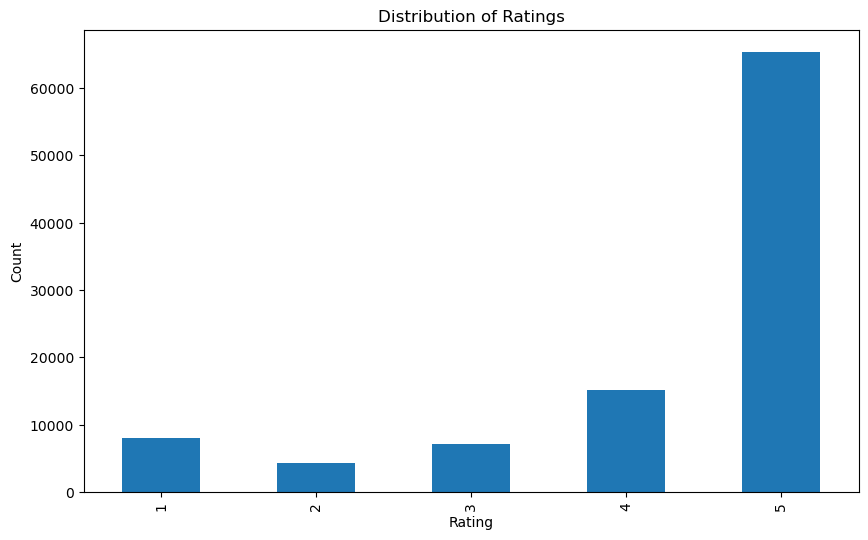

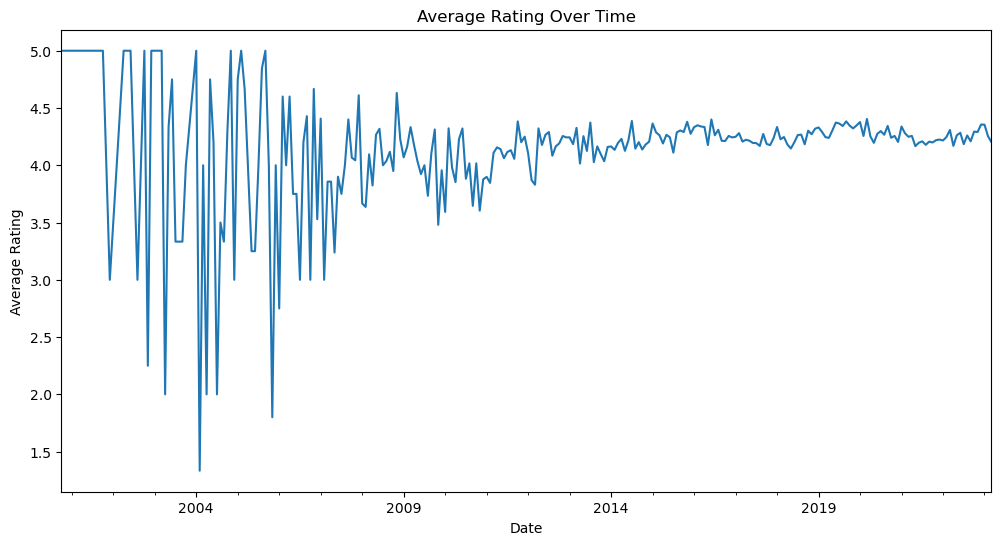


Helpful Votes Statistics:
count    100000.000000
mean          1.594510
std          27.818478
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max        6386.000000
Name: helpful_vote, dtype: float64

Average Rating by Verified Purchase:
verified_purchase
False    4.307846
True     4.242457
Name: rating, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert dataset to pandas DataFrame for easier analysis
df = pd.DataFrame(sample_dataset)

# Basic statistics
print("\nBasic Statistics:")
print(df['rating'].describe())

# Rating distribution
plt.figure(figsize=(10, 6))
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Average rating over time
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
monthly_ratings = df.groupby(df['date'].dt.to_period('M'))['rating'].mean()
plt.figure(figsize=(12, 6))
monthly_ratings.plot(kind='line')
plt.title('Average Rating Over Time')
plt.xlabel('Date')
plt.ylabel('Average Rating')
plt.show()

# Helpful votes analysis
print("\nHelpful Votes Statistics:")
print(df['helpful_vote'].describe())

# Verified vs unverified purchase ratings
print("\nAverage Rating by Verified Purchase:")
print(df.groupby('verified_purchase')['rating'].mean())